# AI61002 - Deep Learning Foundations and Applications
## Assignment 3
### Name: Biswas Tuhin Manik | Roll Number: 22MT3AI38

**Task:** Predict integer ratings (1–5) from Amazon product review text using GRU-based models.

**Input column:** `Text` (full review body)  
**Target column:** `Score` (integer 1–5)

## Imports & Environment Setup

This cell imports all required libraries and sets up the environment.
- `nltk` handles tokenisation and stopword removal.
- `torchtext` builds the integer vocabulary from our token lists.
- `torch.nn` / `torch.optim` provide model layers and optimisers.
- `sklearn.model_selection` handles stratified data splitting.
- `scipy.stats.spearmanr` computes the SROCC evaluation metric.

`torch.manual_seed(42)` and `np.random.seed(42)` fix all random operations so results are reproducible across runs.

In [1]:
# suppress the torchtext deprecation banner
import torchtext; torchtext.disable_torchtext_deprecation_warning()

import os, re, string, warnings

# Numerical / data
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK
import nltk
from nltk.corpus import stopwords       # pre-built English stopword list
from nltk.tokenize import word_tokenize # tokeniser

# PyTorch core
import torch
import torch.nn as nn                              # neural network modules
import torch.optim as optim                        # optimisers
from torch.utils.data import Dataset, DataLoader   # data pipeline
from torch.nn.utils.rnn import pad_sequence        # variable-length batch padding

# torchtext: vocabulary builder
from torchtext.vocab import build_vocab_from_iterator

# sklearn: data splitting
from sklearn.model_selection import train_test_split

# scipy: rank-correlation metric
from scipy.stats import spearmanr

# suppress irrelevant pandas / sklearn warnings
warnings.filterwarnings('ignore')

# NLTK data check
# punkt: tokeniser model (needed by word_tokenize)
# stopwords
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    print("NLTK data found locally. Skipping download.")
except LookupError:
    print("NLTK data not found. Downloading...")
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)

# device selection
# uses GPU (CUDA) when available;
# falls back to CPU otherwise.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# reproducibility seeds
torch.manual_seed(42)   # controls weight init & dropout masks in PyTorch
np.random.seed(42)      # controls numpy random ops


NLTK data found locally. Skipping download.
Using device: cuda


## Question 1 - Load & Preprocess the Dataset

### Step 1: Load the CSV
The dataset has multiple columns. We load the full file first to inspect its structure before filtering. We require only the `Text` column (full review body) as input and `Score` (1–5) as the prediction target.

In [2]:
# Q1 Step 1: load the raw CSV
# dataset has 10 columns, we only need 'Text' and 'Score'.
df = pd.read_csv('Reviews.csv')

print(f"Raw dataset shape  : {df.shape}")          # (rows, cols)
print(f"Columns available  : {df.columns.tolist()}")
df.head(3)   # display first 3 rows as a sanity check


Raw dataset shape  : (568454, 10)
Columns available  : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


### Step 2: Select Columns & Drop Nulls
We discard all columns except `Text` and `Score`, then drop any rows where either value is missing. A missing review or score would cause errors downstream during tokenisation or loss computation.

In [3]:
# Q1 Step 2: select required columns and clean nulls
# input = 'Text', target = 'Score'
# dropping NaN rows, preventing errors during tokenisation
df = df[['Text', 'Score']].dropna().reset_index(drop=True)

print(f"Shape after column selection + dropna : {df.shape}")
print(f"Score unique values                   : {sorted(df['Score'].unique())}")

# Subsample for training efficiency: the full 568K dataset makes the
# GRUCell per-step Python loop very slow. 100K rows preserves the rating
# distribution and gives ~5-6x speedup with minimal impact on SROCC.
MAX_SAMPLES = 100_000
if len(df) > MAX_SAMPLES:
    df = df.sample(n=MAX_SAMPLES, random_state=42).reset_index(drop=True)
    print(f"Downsampled to {len(df):,} rows for training efficiency.")


Shape after column selection + dropna : (568454, 2)
Score unique values                   : [1, 2, 3, 4, 5]
Downsampled to 100,000 rows for training efficiency.


### Step 3: NLTK Text Preprocessing
Raw text cannot be fed directly into a neural network. We apply a four-step cleaning pipeline:
1. **Lowercasing** - unifies `"Great"` and `"great"` as the same token.
2. **Punctuation removal** - punctuation adds noise to the vocabulary with little sentiment signal.
3. **Tokenisation** (`word_tokenize`) - splits the string into a list of word tokens.
4. **Stopword removal** - high-frequency function words (`"the"`, `"is"`, `"of"`) carry minimal discriminative information and inflate vocabulary size unnecessarily.

In [4]:
# Q1 Step 3: NLTK text preprocessing

# build a set for O(1) lookup of stopwords
stop_words = set(stopwords.words('english'))

# str.maketrans maps every punctuation character → deletion (empty string)
# faster than a regex replace loop.
punct_table = str.maketrans('', '', string.punctuation)

def preprocess_text(text: str):
    """
    preprocessing pipeline for a single review string
    Steps:
      1. lowercase the entire string
      2. remove all punctuation using the translation table
      3. tokenise with NLTK word_tokenize
      4. keep only alphabetic tokens not in the stopword list

    returns: list[str] - clean tokens
    """
    text   = text.lower()                         # lowercase
    text   = text.translate(punct_table)          # strip punctuation
    tokens = word_tokenize(text)                  # tokenise
    tokens = [t for t in tokens                   # filter stopwords
              if t.isalpha() and t not in stop_words]
    return tokens

print("Preprocessing all review texts...")
# applying the pipeline to every row. result stored in new 'tokens' column
df['tokens'] = df['Text'].apply(preprocess_text)
print("Done!")

# before/after example
print(f"\nOriginal  : {df['Text'].iloc[0][:120]}...")
print(f"Tokens    : {df['tokens'].iloc[0][:15]}")


Preprocessing all review texts...
Done!

Original  : Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy...
Tokens    : ['tried', 'couple', 'brands', 'glutenfree', 'sandwich', 'cookies', 'best', 'bunch', 'theyre', 'crunchy', 'true', 'texture', 'real', 'cookies', 'arent']


### Step 4: Build Vocabulary & Numericalize
Neural networks work with integers, not strings. `build_vocab_from_iterator` creates a frequency-sorted mapping of `token -> integer index`. Two special tokens are added:
- `<pad>` (index 0) - used to pad shorter sequences in a batch to equal length.
- `<unk>` (index 1) - used for tokens not seen at vocabulary build time.

`min_freq=2` discards tokens that appear only once - these are unlikely to generalise and would waste embedding table rows. After the vocabulary is built, each review's token list is converted to a list of integer indices (numericalization).

In [5]:
# Q1 Step 4: build torchtext vocabulary & numericalize

def yield_tokens(token_lists):
    """Generator that yields one token list at a time
       build_vocab_from_iterator expects an iterable of iterables"""
    for tokens in token_lists:
        yield tokens

# special tokens must come first so they get fixed, low indices:
#   <pad> -> index 0  (used to pad shorter sequences in a batch)
#   <unk> -> index 1  (used for tokens not seen during vocab build)
SPECIAL_TOKENS = ['<pad>', '<unk>']

vocab = build_vocab_from_iterator(
    yield_tokens(df['tokens']),
    specials=SPECIAL_TOKENS,
    min_freq=2          # discard tokens appearing fewer than 2 times
)
# any token not in vocab will map to <unk> by default
vocab.set_default_index(vocab['<unk>'])

# store indices for later use in padding/masking
PAD_IDX = vocab['<pad>']   # 0
UNK_IDX = vocab['<unk>']   # 1

print(f"Vocabulary size : {len(vocab):,}")
print(f"<pad> index     : {PAD_IDX}")
print(f"<unk> index     : {UNK_IDX}")

# convert each token list to a list of integer indices
# empty token lists (e.g., very short reviews) fall back to [UNK_IDX]
# so we always have at least one valid token to process
df['numericalized'] = df['tokens'].apply(
    lambda toks: [vocab[t] for t in toks] if toks else [UNK_IDX]
)
print(f"\nSample numericalized (first 10 ids): {df['numericalized'].iloc[0][:10]}")

# Truncate sequences to MAX_LEN tokens.
# Most rating signal is in the first 150 words; reviews can be 500+ tokens,
# and each extra token adds one GRUCell step. Truncating gives a significant
# speedup with very little accuracy loss.
MAX_LEN = 150
df['numericalized'] = df['numericalized'].apply(lambda toks: toks[:MAX_LEN])

avg_len = df['numericalized'].apply(len).mean()
print(f"Average sequence length after truncation: {avg_len:.1f} tokens")


Vocabulary size : 42,790
<pad> index     : 0
<unk> index     : 1

Sample numericalized (first 10 ids): [25, 296, 203, 781, 1335, 138, 27, 1035, 212, 370]
Average sequence length after truncation: 38.9 tokens


## Question 2 - Rating Distribution & Dataset Split

### Step 1: Visualise Rating Distribution
Before modelling, it is important to understand the class balance. Amazon reviews are typically skewed - users tend to leave reviews when they love or strongly dislike a product, creating a bimodal distribution with many 1-star and 5-star reviews. Identifying this early informs decisions about loss weighting and expected model bias.

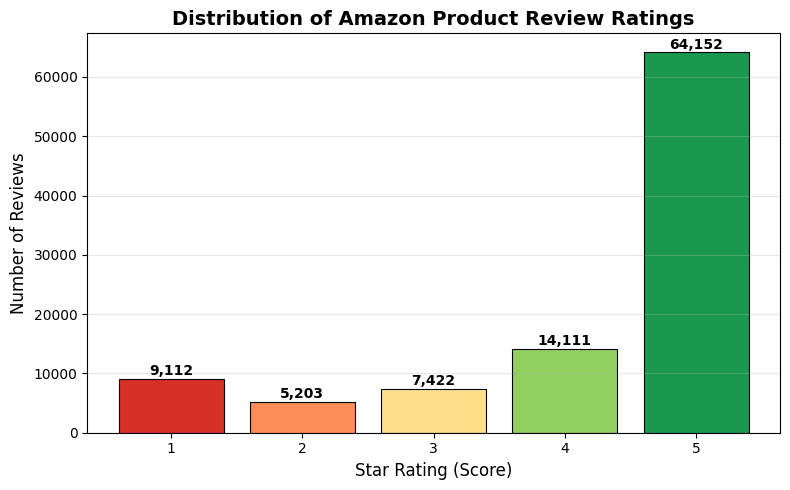

Rating counts:
  Rating 1:  9,112  (  9.1%)
  Rating 2:  5,203  (  5.2%)
  Rating 3:  7,422  (  7.4%)
  Rating 4: 14,111  ( 14.1%)
  Rating 5: 64,152  ( 64.2%)


In [6]:
# Q2 Step 1: rating distribution plot

# count reviews per rating level and sort by rating (1 to 5)
counts = df['Score'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
# diverging colour palette: red (low) -> green (high)
bars = plt.bar(
    counts.index, counts.values,
    color=['#d73027','#fc8d59','#fee08b','#91cf60','#1a9850'],
    edgecolor='black', linewidth=0.8
)

# annotate each bar with its exact count
for bar, val in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{val:,}',
        ha='center', va='bottom', fontweight='bold', fontsize=10
    )

plt.xlabel('Star Rating (Score)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.title('Distribution of Amazon Product Review Ratings', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()

# print a numerical summary alongside the chart
print("Rating counts:")
for score, cnt in counts.items():
    print(f"  Rating {score}: {cnt:>6,}  ({100 * cnt / len(df):5.1f}%)")


### Step 2: Custom Dataset Class & Collate Function
PyTorch's `DataLoader` requires data to be wrapped in a `Dataset` subclass that implements `__len__` and `__getitem__`. Reviews have variable lengths (some are 10 words, others 500), so a custom `collate_fn` is needed to pad all sequences in a batch to the length of the longest one using `pad_sequence`. This ensures every batch is a valid rectangular tensor. The `<pad>` embedding is kept as an all-zero vector via `padding_idx`, so padding tokens do not contribute signal to the hidden state.

In [7]:
# Q2 Step 2: custom PyTorch dataset and collate function

class ReviewDataset(Dataset):
    """
    wraps the numericalized token lists and corresponding labels
    so that PyTorch's DataLoader can iterate over them in mini-batches

    __getitem__ returns a single (text_tensor, label_tensor) pair
    the DataLoader calls __len__ to know the total number of samples
    """
    def __init__(self, texts, labels):
        # texts: list of list[int]  (numericalized token ids per review)
        # labels: list of float       (score 1.0–5.0)
        self.texts  = texts
        self.labels = labels

    def __len__(self):
        # required by DataLoader to compute the number of batches
        return len(self.texts)

    def __getitem__(self, idx):
        # convert Python lists to PyTorch tensors on each fetch
        text  = torch.tensor(self.texts[idx],  dtype=torch.long)    # int64 for embedding lookup
        label = torch.tensor(self.labels[idx], dtype=torch.float32) # float for MSE loss
        return text, label


def collate_fn(batch):
    """
    called by DataLoader to merge a list of (text, label) samples into a batch
    sequences have variable lengths, so we pad the shorter ones to match the
    longest sequence in the current batch using pad_sequence

    pad_sequence output: (batch_size, max_seq_len_in_batch)
    """
    texts, labels = zip(*batch)   # unzip list of (text, label) tuples

    # padding_value=PAD_IDX ensures padding tokens use index 0 (<pad>)
    # batch_first=True -> output shape is (B, T) not (T, B)
    texts_padded  = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    labels_tensor = torch.stack(labels)   # stack scalar tensors into (B,)

    return texts_padded, labels_tensor


### Step 3: Stratified 70 / 15 / 15 Split & DataLoaders
A simple random split can accidentally concentrate one rating class in the test set. Stratified splitting preserves the original rating proportion in each subset. We perform two consecutive splits:
- Split 1: 70% train, 30% temporary pool.
- Split 2: 50% of the pool -> validation, 50% -> test (each 15% of total).

`pin_memory=True` enables faster CPU->GPU data transfer. `num_workers=4` overlaps data loading with GPU computation; set to 0 on Windows to avoid multiprocessing deadlocks.

In [8]:
# Q2 Step 3: stratified 70/15/15 split

texts  = df['numericalized'].tolist()   # input sequences (list of int lists)
labels = df['Score'].tolist()           # targets (integers 1-5)

# first split: carve off 70% for training, keep 30% as temporary pool
# stratify=labels ensures rating proportions are preserved in both halves
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# second split: divide the 30% pool equally -> 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train : {len(X_train):>6,}  ({len(X_train)/len(texts)*100:.1f}%)")
print(f"Val   : {len(X_val):>6,}  ({len(X_val)/len(texts)*100:.1f}%)")
print(f"Test  : {len(X_test):>6,}  ({len(X_test)/len(texts)*100:.1f}%)")

# DataLoader setup
# Batch size 256 (up from 128): fewer optimizer steps per epoch -> faster.
# The model still sees the same data; gradient estimates averaged over a
# larger batch are slightly more stable.
BATCH_SIZE = 256

# wrap raw lists in dataset objects
train_dataset = ReviewDataset(X_train, y_train)
val_dataset   = ReviewDataset(X_val,   y_val)
test_dataset  = ReviewDataset(X_test,  y_test)

NUM_WORKERS = 2 if os.name != 'nt' else 0

# pin_memory=True enables faster CPU->GPU memory transfers via page-locked memory.
# persistent_workers=True keeps worker processes alive between epochs,
# avoiding the overhead of respawning them at the start of each epoch.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=(NUM_WORKERS > 0))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=(NUM_WORKERS > 0))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=(NUM_WORKERS > 0))

print(f"\nBatch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Train : 70,000  (70.0%)
Val   : 15,000  (15.0%)
Test  : 15,000  (15.0%)

Batch size    : 256
Train batches : 274 | Val batches: 59 | Test batches: 59


## Question 3 - GRU-based Model using `nn.GRUCell`

### Classification vs. Regression
We model this as a **regression** problem. Ratings 1–5 are ordinal: predicting 3 when the truth is 4 is a smaller error than predicting 1. CrossEntropyLoss treats all wrong classes equally and ignores this ordering. MSELoss penalises larger errors more heavily, which naturally respects the scale. The SROCC evaluation metric is rank-based and works directly with continuous predictions.

### GRU Theory
A GRU updates its hidden state $h_t$ at each time step using two gates:
- **Update gate** $z_t$: controls how much of the past hidden state to carry forward.
- **Reset gate** $r_t$: controls how much of the past to forget when forming the candidate state.

$$z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z) \quad \text{(update gate)}$$
$$r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r) \quad \text{(reset gate)}$$
$$\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h) \quad \text{(candidate state)}$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

### `nn.GRUCell` vs `nn.GRU`
`nn.GRUCell` processes **one time step at a time**. The sequence loop is written explicitly in Python, giving full control over each step (e.g., custom masking, variable computation). `nn.GRU` runs the entire sequence through a single fused cuDNN CUDA kernel - mathematically identical but significantly faster on GPU. This cell implements the GRUCell version.

#### Architecture chosen
```
Embedding(vocab_size -> 128, padding_idx=0)
  └─ Dropout(0.3)
       └─ GRUCell Layer 1 : input_size=128 -> hidden_size=256
            └─ Dropout(0.3) between layers
                 └─ GRUCell Layer 2 : input_size=256 -> hidden_size=128
                      └─ Dropout(0.3)
                           └─ Linear(128 -> 1)   [regression scalar]
```
The final hidden state after consuming all tokens is passed to a linear layer to produce a single predicted rating.


In [9]:
# Q3: GRU model built step-by-step with nn.GRUCell

class GRUCellModel(nn.Module):
    """
    multi-layer GRU regressor using nn.GRUCell.

    nn.GRUCell(input_size, hidden_size) applies the GRU equations to a
    SINGLE time step: h_t = GRUCell(x_t, h_{t-1})
    We manually iterate over all time steps in the forward() method

    Architecture:
        Embedding -> [GRUCell L1 -> GRUCell L2] over each token -> Linear -> scalar
    """

    def __init__(self, vocab_size, embed_dim, hidden_dims, padding_idx=0, dropout=0.3):
        """
        Args:
            vocab_size: total number of unique tokens (embedding table rows)
            embed_dim: dimensionality of each token's dense embedding vector
            hidden_dims: list of hidden sizes per GRU layer
            padding_idx: <pad> token index, its embedding row stays zero
            dropout: probability of zeroing a unit (regularisation)
        """
        super(GRUCellModel, self).__init__()

        # store for use in forward()
        self.hidden_dims = hidden_dims
        self.num_layers  = len(hidden_dims)

        # 1. Embedding layer
        # maps integer token ids -> dense float vectors of size embed_dim
        # padding_idx=PAD_IDX keeps the <pad> embedding as an all-zero vector
        # so padding tokens do not contribute signal to the hidden state
        self.embedding     = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.embed_dropout = nn.Dropout(dropout)   # regularise embeddings

        # 2. Stack of GRUCell layers
        # nn.ModuleList ensures PyTorch registers each cell's parameters
        # so they appear in model.parameters() and are saved/loaded correctly
        self.gru_cells = nn.ModuleList()
        in_size = embed_dim                         # first layer input = embedding dim
        for h_dim in hidden_dims:
            self.gru_cells.append(nn.GRUCell(in_size, h_dim))
            in_size = h_dim                         # next layer input = this layer's output

        # 3. Output head
        self.dropout = nn.Dropout(dropout)
        # maps the last GRU layer's hidden state -> single regression scalar
        self.fc = nn.Linear(hidden_dims[-1], 1)

    def forward(self, x):
        """
        Args: x: (batch_size, seq_len) - padded integer token indices
        Returns: (batch_size,) - predicted ratings as real-valued scalars
        """
        batch_size, seq_len = x.size()

        # embed all tokens at once: (B, T) → (B, T, embed_dim)
        embedded = self.embed_dropout(self.embedding(x))

        # initialise hidden states for all layers to zero vectors
        # shape of h[l]: (batch_size, hidden_dims[l])
        h = [
            torch.zeros(batch_size, self.hidden_dims[l], device=x.device)
            for l in range(self.num_layers)
        ]

        # Manual recurrence over the sequence
        # for each time step t (i.e., each token position):
        # - extract the embedding for that token position across the batch
        # - feed it through Layer 0's GRUCell -> update h[0]
        # - Feed h[0] (with dropout) through Layer 1's GRUCell -> update h[1]
        # - ... repeat for deeper layers
        for t in range(seq_len):
            inp  = embedded[:, t, :]           # (B, embed_dim) - token at step t

            # layer 0: takes the raw embedding
            h[0] = self.gru_cells[0](inp, h[0])

            # layers 1..N-1: take the previous layer's hidden state as input
            for l in range(1, self.num_layers):
                h[l] = self.gru_cells[l](self.dropout(h[l-1]), h[l])

        # after processing all tokens, h[-1] summarises the entire sequence
        # pass it through a linear layer to get the predicted rating
        out = self.fc(self.dropout(h[-1]))     # (B, 1)
        return out.squeeze(-1)                 # (B,)  - remove trailing dim


## Question 4 - Model Summary, Parameter Count & Loss Function

### Step 1: Instantiate and Inspect the Model
After defining the architecture, we instantiate it with chosen hyperparameters and move it to the GPU with `.to(device)`. Printing the model shows all sub-modules and their configuration. Counting trainable parameters reveals the model's capacity - a key factor in estimating memory usage, training time, and overfitting risk. `p.numel()` returns the total number of scalar values in each parameter tensor.

In [10]:
# Q4: Instantiate and inspect the GRUCell model

# hyperparameters
VOCAB_SIZE  = len(vocab)      # dynamic - depends on the training corpus
EMBED_DIM   = 128             # each token is represented as a 128-d vector
HIDDEN_DIMS = [256, 128]      # two GRU layers: first 256 units, second 128 units
DROPOUT     = 0.3             # 30% dropout for regularisation

model_gru_cell = GRUCellModel(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dims = HIDDEN_DIMS,
    padding_idx = PAD_IDX,
    dropout     = DROPOUT
).to(device)   # move all parameters to GPU (or CPU if no GPU available)

print("=" * 60)
print("      Model Architecture — nn.GRUCell")
print("=" * 60)
print(model_gru_cell)   # shows all sub-modules and their shapes

# Parameter count
# p.numel() returns the total number of scalar values in tensor p.
total_params     = sum(p.numel() for p in model_gru_cell.parameters())
trainable_params = sum(p.numel() for p in model_gru_cell.parameters()
                       if p.requires_grad)   # frozen params would have requires_grad=False

print(f"\n{'─'*60}")
print(f"  Total parameters     : {total_params:>12,}")
print(f"  Trainable parameters : {trainable_params:>12,}")
print(f"{'─'*60}")

# Per-layer breakdown
print("\nPer-layer parameter breakdown:")
for name, param in model_gru_cell.named_parameters():
    if param.requires_grad:
        print(f"  {name:<40s}  {param.numel():>10,}  {tuple(param.shape)}")


      Model Architecture — nn.GRUCell
GRUCellModel(
  (embedding): Embedding(42790, 128, padding_idx=0)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (gru_cells): ModuleList(
    (0): GRUCell(128, 256)
    (1): GRUCell(256, 128)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

────────────────────────────────────────────────────────────
  Total parameters     :    5,921,921
  Trainable parameters :    5,921,921
────────────────────────────────────────────────────────────

Per-layer parameter breakdown:
  embedding.weight                           5,477,120  (42790, 128)
  gru_cells.0.weight_ih                         98,304  (768, 128)
  gru_cells.0.weight_hh                        196,608  (768, 256)
  gru_cells.0.bias_ih                              768  (768,)
  gru_cells.0.bias_hh                              768  (768,)
  gru_cells.1.weight_ih                         98,304  (384, 256)
  gru_cells.1.weight_hh        

### Step 2: Loss Function
Since we frame the problem as regression, we use **Mean Squared Error (MSE) Loss**:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

MSE penalises large prediction errors quadratically - a prediction of 1 when the truth is 5 incurs 16× more loss than a prediction of 3 when the truth is 5. This is the correct behaviour for an ordinal scale. If we had chosen classification, we would use CrossEntropyLoss instead.

In [11]:
# Q4: define the loss function

# nn.MSELoss() computes mean((prediction - target)^2) over the batch.
# suitable for regression tasks where the distance between labels is meaningful.
criterion = nn.MSELoss()

print("Loss Function :", criterion)

Loss Function : MSELoss()


## Question 5 - Train with Adam Optimizer

### Step 1: Training & Evaluation Helper Functions
Two reusable functions are defined here:
- `train_epoch`: runs one full pass over the training DataLoader, computing predictions, backpropagating gradients, and updating parameters. **Gradient clipping** (`clip_grad_norm_`, max_norm=1.0) prevents exploding gradients - a common instability in RNNs caused by gradients growing exponentially through long sequences via the chain rule.
- `evaluate`: runs one full pass over any DataLoader **without** gradient computation (`torch.no_grad()`), saving memory and time. `model.eval()` disables dropout so evaluation is deterministic.

#### Adam Optimizer
Adam (Adaptive Moment Estimation) maintains per-parameter learning rates, adapting them using:
- **First moment** $m_t$ — exponential moving average of gradients (like momentum).
- **Second moment** $v_t$ — exponential moving average of squared gradients (like RMSProp).

$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Adam converges faster than SGD on most NLP tasks and is robust to the choice of learning rate.


In [12]:
# Q5: training and evaluation helper functions

def train_epoch(model, loader, optimizer, criterion, device):
    """
    run one full pass over the training data (one epoch)

    Steps per batch:
    - move data to device (GPU/CPU)
    - zero accumulated gradients from the previous step
    - Forward pass: compute predictions
    - compute loss between predictions and ground truth
    - Backward pass: compute gradients via autograd
    - clip gradients to prevent exploding gradients in RNNs
    - update parameters with the optimizer
    - accumulate the batch loss

    Returns: average MSE loss over all batches in this epoch
    """
    model.train()        # enable dropout and batch-norm training behaviour
    running_loss = 0.0

    for texts_batch, labels_batch in loader:
        texts_batch  = texts_batch.to(device)    # (B, T) integer tensor
        labels_batch = labels_batch.to(device)   # (B,)   float tensor

        optimizer.zero_grad()                    # clear gradients from previous batch

        preds = model(texts_batch)               # (B,) predicted ratings
        loss  = criterion(preds, labels_batch)   # MSE between preds and truth

        loss.backward()                          # compute del_loss/del_params for all params

        # clip gradient norm to 1.0 - prevents exploding gradients in the RNN
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()                         # apply gradient update

        running_loss += loss.item()              # .item() extracts scalar from tensor

    return running_loss / len(loader)            # return mean loss over all batches


def evaluate(model, loader, criterion, device):
    """
    evaluate the model on a data loader without updating weights

    torch.no_grad() disables gradient computation entirely, saving memory
    and speeding up the forward pass during validation/test

    Returns: average MSE loss over all batches
    """
    model.eval()         # disable dropout (use all neurons at full weight)
    running_loss = 0.0

    with torch.no_grad():
        for texts_batch, labels_batch in loader:
            texts_batch  = texts_batch.to(device)
            labels_batch = labels_batch.to(device)
            preds        = model(texts_batch)
            running_loss += criterion(preds, labels_batch).item()

    return running_loss / len(loader)


### Step 2: Train the GRUCell Model
The **Adam optimizer** adapts the learning rate per-parameter using first and second moment estimates of the gradients, converging faster than plain SGD on most NLP tasks. `ReduceLROnPlateau` halves the learning rate when validation loss does not improve for 2 consecutive epochs (`patience=2`), allowing large updates early and fine-grained updates later.

In [13]:
# Q5: Train the GRUCell model

LEARNING_RATE = 1e-3   # Adam default
NUM_EPOCHS    = 7      # reduced from 10; early stopping catches convergence earlier

# Adam optimizer - adaptively tunes learning rate per parameter
optimizer_cell = optim.Adam(model_gru_cell.parameters(), lr=LEARNING_RATE)

# ReduceLROnPlateau: halves LR if val loss does not improve for 2 epochs
# mode='min' means we want the monitored metric (val loss) to decrease
scheduler_cell = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cell, mode='min', patience=2, factor=0.5, verbose=True
)

# lists to store per-epoch losses for plotting
train_losses_cell = []
val_losses_cell   = []

# Early stopping: halt if val loss stops improving for PATIENCE consecutive
# epochs. We save the best checkpoint so evaluation always uses the
# best weights, not the last ones.
PATIENCE         = 2
best_val_loss    = float('inf')
patience_counter = 0

print(f"Training GRUCell model — up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})\n")
print(f"{'Epoch':>6} | {'Train MSE':>10} | {'Val MSE':>9}")
print("-" * 35)

for epoch in range(1, NUM_EPOCHS + 1):
    # one full pass over training data, updates model weights
    tr_loss = train_epoch(model_gru_cell, train_loader,
                          optimizer_cell, criterion, device)

    # one full pass over validation data, no weight updates
    val_loss = evaluate(model_gru_cell, val_loader, criterion, device)

    # step the scheduler: if val_loss stagnates, LR is reduced
    scheduler_cell.step(val_loss)

    # record for plotting
    train_losses_cell.append(tr_loss)
    val_losses_cell.append(val_loss)

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {val_loss:>9.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model_gru_cell.state_dict(), 'best_grucell.pt')  # save best weights
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

# restore best weights before evaluation
model_gru_cell.load_state_dict(torch.load('best_grucell.pt'))
NUM_EPOCHS = len(train_losses_cell)   # update for accurate plot x-axis
print("\nTraining complete!")


Training GRUCell model — up to 7 epochs (early stopping patience=2)

 Epoch |  Train MSE |   Val MSE
-----------------------------------
     1 |     1.9755 |    1.0618
     2 |     1.0651 |    0.8769
     3 |     0.8862 |    0.8319
     4 |     0.7918 |    0.7938
     5 |     0.7073 |    0.7790
     6 |     0.6603 |    0.7436
     7 |     0.6071 |    0.7402

Training complete!


### Step 3: Training & Validation Loss Curve
Plotting both curves on the same axes is the primary diagnostic tool for training:
- Both losses **decreasing together** -> model is learning well.
- Training loss low, validation loss high and rising -> **overfitting** (model memorising training data).
- Both losses high and flat -> **underfitting** (model too simple or learning rate too low).

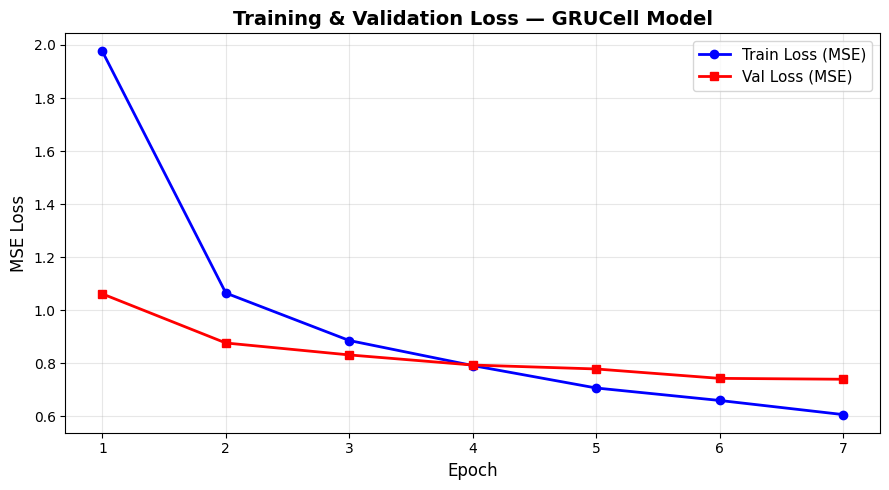

In [14]:
# Q5: plot training and validation loss curves

epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, train_losses_cell, 'b-o',
         label='Train Loss (MSE)', linewidth=2, markersize=6)
plt.plot(epochs_range, val_losses_cell, 'r-s',
         label='Val Loss (MSE)', linewidth=2, markersize=6)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Training & Validation Loss — GRUCell Model', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(list(epochs_range))   # show every epoch on the x-axis
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curve_grucell.png', dpi=150)
plt.show()


## Question 6 - Test Set Prediction & SROCC

### Step 1: Prediction Helper
`get_predictions` iterates over a DataLoader in inference mode, collecting all raw model outputs and ground truth labels into NumPy arrays. `.cpu().numpy()` copies tensors from GPU memory to CPU-accessible NumPy arrays. `model.eval()` and `torch.no_grad()` are both required: `eval()` disables dropout, `no_grad()` disables the autograd graph to save memory.

In [15]:
# Q6: helper to collect all predictions from a DataLoader

def get_predictions(model, loader, device):
    """
    run the model over an entire DataLoader (no gradient tracking)
    and collect all predictions and ground truth labels

    Returns:
        ground_truth: np.ndarray of shape (N,) - true ratings
        predictions: np.ndarray of shape (N,) - predicted ratings (raw floats)
    """
    model.eval()   # disable dropout for deterministic inference
    all_preds, all_labels = [], []

    with torch.no_grad():              # no gradients needed during inference
        for texts_batch, labels_batch in loader:
            texts_batch = texts_batch.to(device)

            preds = model(texts_batch)   # (B,) raw float predictions

            # .cpu().numpy() copies from GPU memory to a NumPy array
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.numpy())   # already on CPU

    return np.array(all_labels), np.array(all_preds)


### Step 2: Evaluate & Compute SROCC
Raw regression outputs are unbounded floats, so we clamp them to `[1.0, 5.0]` — the valid rating range. **Spearman's Rank Order Correlation Coefficient (SROCC)** then measures how well the *ranking order* of our predictions matches the ranking order of the true labels:

$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$

where $d_i$ is the difference in ranks for sample $i$. SROCC = 1.0 is perfect; SROCC = 0.0 means no monotonic relationship. It is preferred over Pearson correlation here because it is robust to outliers and does not assume a linear relationship.

#### Prediction clamping
The regression head outputs unbounded floats. We clamp predictions to $[1, 5]$ because:
- The true label space is $\{1, 2, 3, 4, 5\}$.
- Unclamped predictions like 0.3 or 5.8 would inflate RMSE without representing any valid label.


  Test Results — GRUCell Model
  SROCC  : 0.6512   (p = 0.00e+00)
  MSE    : 0.7521
  RMSE   : 0.8672


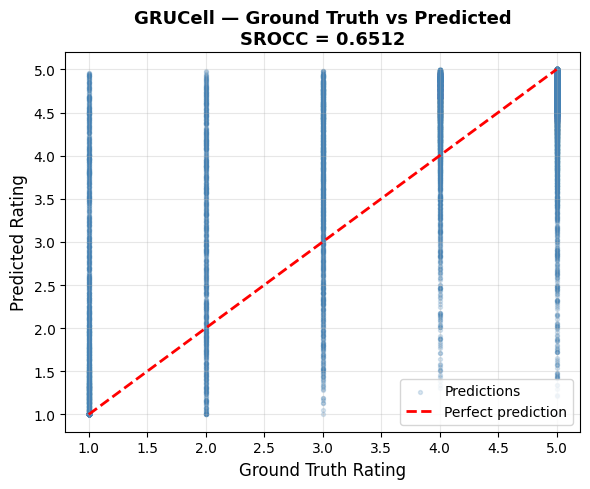

In [16]:
# Q6: evaluate GRUCell model on the held-out test set

gt_cell, pred_cell = get_predictions(model_gru_cell, test_loader, device)

# clamp raw float predictions to the valid rating range [1.0, 5.0]
# e.g. raw output of 5.3 becomes 5.0, -0.2 becomes 1.0
pred_cell_clamped = np.clip(pred_cell, 1.0, 5.0)

# Spearman Rank Order Correlation Coefficient
# scipy.stats.spearmanr returns (correlation, p-value)
# p-value < 0.05 indicates the correlation is statistically significant
srocc_cell, pval_cell = spearmanr(gt_cell, pred_cell_clamped)

# Additional regression metrics
mse_cell  = np.mean((pred_cell_clamped - gt_cell) ** 2)
rmse_cell = np.sqrt(mse_cell)   # in the same unit as ratings (stars)

print("=" * 50)
print("  Test Results — GRUCell Model")
print("=" * 50)
print(f"  SROCC  : {srocc_cell:.4f}   (p = {pval_cell:.2e})")
print(f"  MSE    : {mse_cell:.4f}")
print(f"  RMSE   : {rmse_cell:.4f}")
print("=" * 50)

# scatter plot: ground truth vs predicted
# points along the red dashed diagonal = perfect prediction
plt.figure(figsize=(6, 5))
plt.scatter(gt_cell, pred_cell_clamped,
            alpha=0.2, s=8, color='steelblue', label='Predictions')
plt.plot([1, 5], [1, 5], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Ground Truth Rating', fontsize=12)
plt.ylabel('Predicted Rating', fontsize=12)
plt.title(f'GRUCell — Ground Truth vs Predicted\nSROCC = {srocc_cell:.4f}',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_grucell.png', dpi=150)
plt.show()


## Question 7 - Redesign with `nn.GRU` & Comparison

### Step 1: Redesign Using `nn.GRU`
`nn.GRU` implements the identical GRU equations but runs the **entire sequence in a single fused CUDA/cuDNN kernel**, making it substantially faster per epoch on GPU compared to the Python-level `for t in range(seq_len)` loop used in `nn.GRUCell`. After processing the sequence, `nn.GRU` returns:
- `output`: `(B, T, H)` - hidden state at every token position.
- `h_n`: `(num_layers, B, H)` - final hidden state per layer.

We take `h_n[-1]` (last layer's final hidden state) as the fixed-size sequence representation, then pass it to a linear layer for the rating prediction.

In [17]:
# Q7: GRU model rebuilt with nn.GRU

class GRUModel(nn.Module):
    """
    same architecture as GRUCellModel, but uses PyTorch's built-in
    nn.GRU which processes the entire sequence in a single cuDNN call

    Architecture: Embedding -> Dropout -> nn.GRU (2 layers) -> Dropout -> Linear -> scalar
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, padding_idx=0, dropout=0.3):
        """
        Args:
            vocab_size: vocabulary size (embedding table rows)
            embed_dim: token embedding dimension
            hidden_dim: hidden state size for ALL GRU layers
                          (nn.GRU uses the same size across layers)
            num_layers: number of stacked GRU layers
            padding_idx: <pad> token index
            dropout: dropout probability
        """
        super(GRUModel, self).__init__()

        # Embedding (same as GRUCellModel)
        self.embedding     = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.embed_dropout = nn.Dropout(dropout)

        # nn.GRU: processes the ENTIRE sequence at once
        # dropout= here applies between GRU layers (not after the last layer),
        # and is only applied when num_layers > 1
        self.gru = nn.GRU(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,     # input shape: (B, T, E)
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = False     # unidirectional: left -> right
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)   # regression output scalar

    def forward(self, x):
        """
        Args: x: (B, T) - padded integer token indices

        Returns: (B,) - predicted ratings as real-valued scalars
        """
        # 1: Embed tokens -> (B, T, embed_dim)
        embedded = self.embed_dropout(self.embedding(x))

        # 2: run the GRU over all time steps in one call
        # output: (B, T, hidden_dim) - hidden state at every token position
        # h_n: (num_layers, B, hidden_dim) - final hidden state per layer
        _, h_n = self.gru(embedded)

        # 3: use the last layer's final hidden state as the sequence summary
        last_h = h_n[-1]                    # (B, hidden_dim)

        # 4: project to a single scalar rating prediction
        out = self.fc(self.dropout(last_h)) # (B, 1)
        return out.squeeze(-1)              # (B,)


### Step 2: Instantiate `nn.GRU` Model
We use `hidden_dim=256` for both layers to match the overall capacity of the GRUCell model. The parameter count will differ slightly since `nn.GRU` uses a uniform hidden size across all layers, whereas the GRUCell model used `[256, 128]`. Both are moved to the same device for a fair comparison.

In [18]:
# Q7: Instantiate the nn.GRU model

# mirror the GRUCell model's capacity for a fair comparison:
# GRUCell:  layer 1 = 256 units, layer 2 = 128 units
# nn.GRU :  both layers = 256 units (nn.GRU uses one uniform hidden_dim)
#           This slightly increases nn.GRU's capacity, which is acceptable
#           since we want to compare at least equivalent-order-of-magnitude scale.
GRU_HIDDEN_DIM = 256
GRU_NUM_LAYERS = 2

model_gru = GRUModel(
    vocab_size  = VOCAB_SIZE,
    embed_dim   = EMBED_DIM,
    hidden_dim  = GRU_HIDDEN_DIM,
    num_layers  = GRU_NUM_LAYERS,
    padding_idx = PAD_IDX,
    dropout     = DROPOUT
).to(device)   # send all parameters to GPU

print("=" * 60)
print("      Model Architecture — nn.GRU")
print("=" * 60)
print(model_gru)

# count trainable parameters (for comparison with GRUCell model)
trainable_gru = sum(p.numel() for p in model_gru.parameters() if p.requires_grad)
print(f"\nTrainable parameters (nn.GRU): {trainable_gru:,}")


      Model Architecture — nn.GRU
GRUModel(
  (embedding): Embedding(42790, 128, padding_idx=0)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (gru): GRU(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

Trainable parameters (nn.GRU): 6,168,577


### Step 3: Train the `nn.GRU` Model
Identical training configuration as the GRUCell model - same optimizer (Adam, lr=1e-3), same scheduler (ReduceLROnPlateau, patience=2), same number of epochs, and same loss function (MSELoss). Keeping all training hyperparameters constant ensures that any difference in final SROCC is attributable to the model architecture (GRUCell vs GRU), not the training setup.

In [19]:
# Q7: Train the nn.GRU model
# identical training setup to the GRUCell model for a fair comparison

optimizer_gru = optim.Adam(model_gru.parameters(), lr=LEARNING_RATE)
scheduler_gru = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gru, mode='min', patience=2, factor=0.5, verbose=True
)

train_losses_gru = []
val_losses_gru   = []

best_val_loss_gru    = float('inf')
patience_counter_gru = 0

print(f"Training nn.GRU model — up to {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})\n")
print(f"{'Epoch':>6} | {'Train MSE':>10} | {'Val MSE':>9}")
print("-" * 35)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss  = train_epoch(model_gru, train_loader,
                           optimizer_gru, criterion, device)
    val_loss = evaluate(model_gru, val_loader, criterion, device)
    scheduler_gru.step(val_loss)

    train_losses_gru.append(tr_loss)
    val_losses_gru.append(val_loss)
    print(f"{epoch:>6} | {tr_loss:>10.4f} | {val_loss:>9.4f}")

    if val_loss < best_val_loss_gru:
        best_val_loss_gru    = val_loss
        patience_counter_gru = 0
        torch.save(model_gru.state_dict(), 'best_gru.pt')
    else:
        patience_counter_gru += 1
        if patience_counter_gru >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

model_gru.load_state_dict(torch.load('best_gru.pt'))
NUM_EPOCHS_GRU = len(train_losses_gru)   # may differ if stopped earlier
print("\nTraining complete!")


Training nn.GRU model — up to 7 epochs (early stopping patience=2)

 Epoch |  Train MSE |   Val MSE
-----------------------------------
     1 |     1.8416 |    1.0341
     2 |     1.0131 |    0.8675
     3 |     0.8582 |    0.8127
     4 |     0.7570 |    0.7604
     5 |     0.6895 |    0.7758
     6 |     0.6343 |    0.7867

Early stopping triggered at epoch 6.

Training complete!


### Step 4: Evaluate `nn.GRU` on the Test Set
Same evaluation procedure as Question 6: collect predictions, clamp to `[1, 5]`, then compute SROCC, MSE, and RMSE. These numbers will be compared side-by-side with the GRUCell results in the next cell.

In [20]:
# Q7: evaluate nn.GRU on the test set

gt_gru, pred_gru = get_predictions(model_gru, test_loader, device)
pred_gru_clamped = np.clip(pred_gru, 1.0, 5.0)   # clamp to valid rating range [1, 5]

# SROCC between ground truth and predicted ratings
srocc_gru, pval_gru = spearmanr(gt_gru, pred_gru_clamped)
mse_gru  = np.mean((pred_gru_clamped - gt_gru) ** 2)
rmse_gru = np.sqrt(mse_gru)

print("=" * 50)
print("  Test Results — nn.GRU Model")
print("=" * 50)
print(f"  SROCC  : {srocc_gru:.4f}   (p = {pval_gru:.2e})")
print(f"  MSE    : {mse_gru:.4f}")
print(f"  RMSE   : {rmse_gru:.4f}")
print("=" * 50)


  Test Results — nn.GRU Model
  SROCC  : 0.6280   (p = 0.00e+00)
  MSE    : 0.7648
  RMSE   : 0.8745


### Step 5: Side-by-Side Comparison
The two models are plotted on the same figure for a direct visual comparison of their learning curves. The summary table below the plot consolidates SROCC, MSE, RMSE, and parameter counts into a single view.

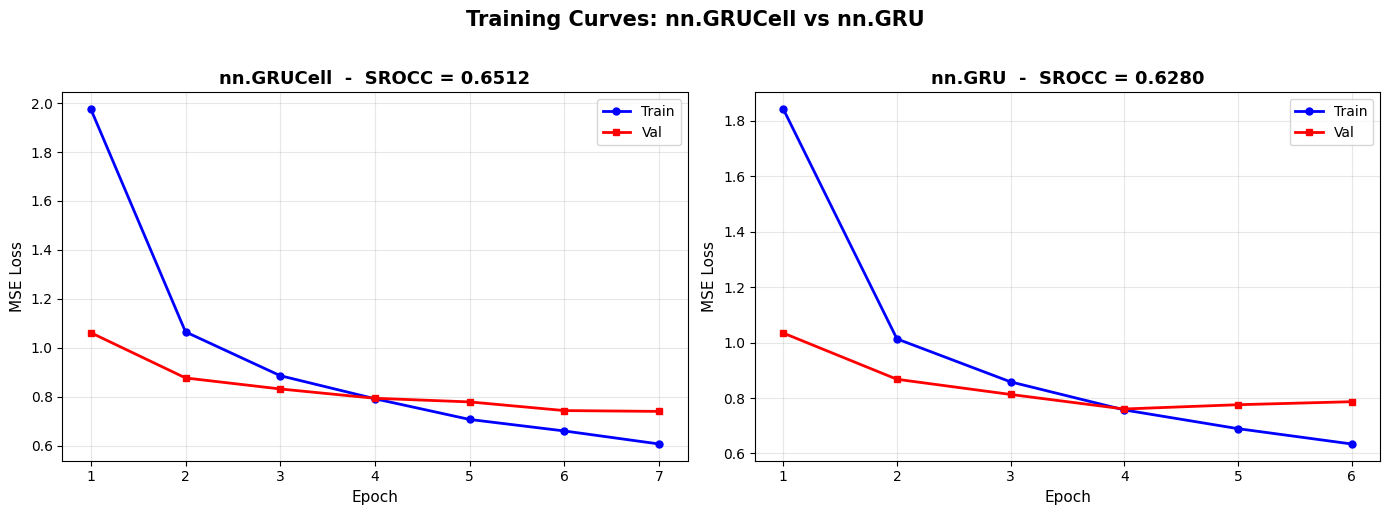


                    FINAL COMPARISON SUMMARY                     
Metric                                nn.GRUCell       nn.GRU
-----------------------------------------------------------------
SROCC (test, higher is better)            0.6512       0.6280
MSE   (test, lower is better)             0.7521       0.7648
RMSE  (test)                              0.8672       0.8745
Trainable parameters                   5,921,921    6,168,577


In [21]:
# Q7: side-by-side comparison - loss curves + metrics table

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot loss curves for both models on separate subplots
for ax, tr_l, va_l, label, srocc, n_ep in [
    (axes[0], train_losses_cell, val_losses_cell, 'nn.GRUCell', srocc_cell, NUM_EPOCHS),
    (axes[1], train_losses_gru,  val_losses_gru,  'nn.GRU',     srocc_gru,  NUM_EPOCHS_GRU),
]:
    ep_range = range(1, n_ep + 1)
    ax.plot(ep_range, tr_l, 'b-o', label='Train', lw=2, ms=5)
    ax.plot(ep_range, va_l, 'r-s', label='Val',   lw=2, ms=5)
    ax.set_title(f'{label}  -  SROCC = {srocc:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('MSE Loss', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(list(ep_range))

plt.suptitle('Training Curves: nn.GRUCell vs nn.GRU',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison_curves.png', dpi=150)
plt.show()

# Final summary table
print("\n" + "=" * 65)
print(f"{'FINAL COMPARISON SUMMARY':^65}")
print("=" * 65)
print(f"{'Metric':<35} {'nn.GRUCell':>12} {'nn.GRU':>12}")
print("-" * 65)
print(f"{'SROCC (test, higher is better)':<35} {srocc_cell:>12.4f} {srocc_gru:>12.4f}")
print(f"{'MSE   (test, lower is better)':<35} {mse_cell:>12.4f} {mse_gru:>12.4f}")
print(f"{'RMSE  (test)':<35} {rmse_cell:>12.4f} {rmse_gru:>12.4f}")
print(f"{'Trainable parameters':<35} {trainable_params:>12,} {trainable_gru:>12,}")
print("=" * 65)


## Discussion - `nn.GRUCell` vs `nn.GRU`

| Aspect | `nn.GRUCell` | `nn.GRU` |
|---|---|---|
| **Execution** | Python loop over each time step | Single fused cuDNN CUDA kernel |
| **Speed** | Slower (interpreter overhead per step) | Faster (optimised GPU kernel) |
| **Flexibility** | Full per-step control (masking, custom logic) | Fixed recurrence, no per-step hooks |
| **Math** | Identical GRU equations | Identical GRU equations |
| **Typical use** | Research / custom RNN variants | Production / standard GRU usage |

**SROCC comparison:** Both models implement the same GRU equations and are trained under identical conditions. Any difference in SROCC is attributable to training dynamics (e.g., gradient update numerics, cuDNN precision) rather than architectural differences.

**Speed:** `nn.GRU` is significantly faster per epoch on the RTX 3050.

**Conclusion:** For production use, prefer `nn.GRU`. Use `nn.GRUCell` only when you need custom per-step logic (e.g., attention injection at each step, scheduled sampling, or non-standard gating).